# Random Sample + Collate + Spectrogram
This cell pair picks a random local LibriSpeech sample, applies `collate_fn`, and visualizes the resulting mel spectrogram.

In [ ]:
import matplotlib.pyplot as plt
import torch
import torchaudio
from torch.utils.data import DataLoader
from model.helpers import collate_fn_speed_perturb, collate_fn_test, blank, idx2char, get_dataset_lengths, BucketBatchSampler

import os
from dotenv import load_dotenv

load_dotenv()
root = str(os.getenv("ROOT"))

train_ds = torchaudio.datasets.LIBRISPEECH(root=root, url="test-clean", download=False)

print("Pre-computing lengths...")
train_lengths = get_dataset_lengths(train_ds)
train_sampler = BucketBatchSampler(train_lengths, batch_size=64, shuffle=True)

train_loader = DataLoader(train_ds, batch_sampler=train_sampler, collate_fn=collate_fn_speed_perturb,
                          num_workers=4, pin_memory=True)

batch = next(iter(train_loader))
spectrogram_batch, targets_batch, input_lengths, target_lengths = batch

idx = torch.randint(0, len(spectrogram_batch), (1,)).item()
spec = spectrogram_batch[idx].cpu().numpy()
true_len = int(input_lengths[idx].item())

print(f"Batch size: {len(spectrogram_batch)}")
print(f"Sample {idx} | true frames: {true_len} | padded shape: {spec.shape}")
print(f"Input lengths in this batch: {input_lengths.tolist()}")

plt.figure(figsize=(12, 4))
plt.imshow(spec[:, :], aspect="auto", origin="lower", cmap="magma")
plt.title(f"Mel Spectrogram — sample {idx} (cropped to true length)")
plt.xlabel("Time Frames")
plt.ylabel("Mel Bins")
plt.colorbar(label="dB")
plt.tight_layout()
plt.show()


In [ ]:
# Get one collated batch (this is your "df" / batch object)
df = next(iter(train_loader))
spectrogram_batch, targets_batch, input_lengths, target_lengths = df

print(f"Batch size: {len(spectrogram_batch)}")
print(f"Input lengths (first 5): {input_lengths[:5].tolist()}")
print(f"Target lengths (first 5): {target_lengths[:5].tolist()}")

# Show spectrogram of one random item from the collated batch
idx = torch.randint(0, len(spectrogram_batch), (1,)).item()
spec = spectrogram_batch[idx].detach().cpu().numpy()  # (n_mels, time)

# Crop to true (unpadded) length so padding is not shown
original_length = int(input_lengths[idx].item())
spec_no_pad = spec[:]
print(f"Original audio length (sample {idx}): {original_length} frames")

# spec_no_pad = spec[:, :original_length]
plt.figure(figsize=(12, 4))
plt.imshow(spec_no_pad, aspect="auto", origin="lower", cmap="magma")
plt.title(f"Collated Batch Spectrogram (sample index={idx}")
plt.xlabel("Time Frames")
plt.ylabel("Mel Bins")
plt.colorbar(label="dB")
plt.tight_layout()
plt.show()

Batch size: 64
Input lengths (first 5): [212, 237, 213, 214, 194]
Target lengths (first 5): [13, 28, 26, 27, 36]
Original audio length (sample 14): 196 frames


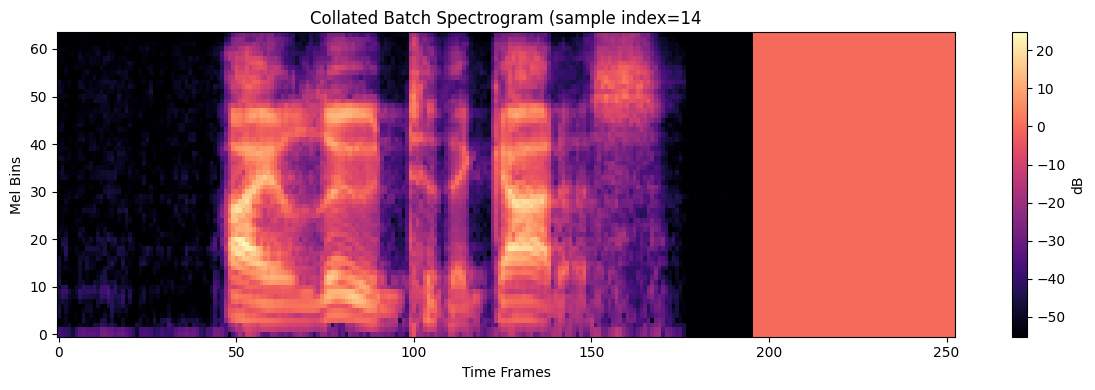

In [ ]:
# Get one collated batch (this is your "df" / batch object)
df = next(iter(train_loader))
spectrogram_batch, targets_batch, input_lengths, target_lengths = df

print(f"Batch size: {len(spectrogram_batch)}")
print(f"Input lengths (first 5): {input_lengths[:5].tolist()}")
print(f"Target lengths (first 5): {target_lengths[:5].tolist()}")

# Show spectrogram of one random item from the collated batch
idx = torch.randint(0, len(spectrogram_batch), (1,)).item()
spec = spectrogram_batch[idx].detach().cpu().numpy()  # (n_mels, time)

# Crop to true (unpadded) length so padding is not shown
original_length = int(input_lengths[idx].item())
spec_no_pad = spec[:]
print(f"Original audio length (sample {idx}): {original_length} frames")

# spec_no_pad = spec[:, :original_length]
plt.figure(figsize=(12, 4))
plt.imshow(spec_no_pad, aspect="auto", origin="lower", cmap="magma")
plt.title(f"Collated Batch Spectrogram (sample index={idx}")
plt.xlabel("Time Frames")
plt.ylabel("Mel Bins")
plt.colorbar(label="dB")
plt.tight_layout()
plt.show()

In [ ]:
spectrogram_batch, targets_batch, input_lengths, target_lengths = df

sample_idx = idx if 0 <= idx < len(spectrogram_batch) else 0
input_len = int(input_lengths[sample_idx].item())
target_len = int(target_lengths[sample_idx].item())

# Show the end of the spectrogram to inspect zero-padding
tail_frames = 10
print(f"\nSpectrogram tail (first 5 mel bins x last {tail_frames} frames):")
print(spectrogram_batch[sample_idx, :5, -tail_frames:])

# How many mel bins are non-zero in each of the last frames
print(f"\nNon-zero mel-bin count per last {tail_frames} frames:")
print((spectrogram_batch[sample_idx, :, -tail_frames:] != 0).sum(dim=0))

print(f"Sample index: {sample_idx}")
print(f"Spectrogram shape (padded): {tuple(spectrogram_batch[sample_idx].shape)}")
print(f"Input length (true frames): {input_len}")
print(f"Target length (true tokens): {target_len}")

print("\nTarget tokens (unpadded):")
print(targets_batch[sample_idx, :target_len])

print("\nSpectrogram snippet (first 5 mel bins x first 10 frames):")
print(spectrogram_batch[sample_idx, :5, :10])


Spectrogram tail (first 5 mel bins x last 10 frames):
tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]])

Non-zero mel-bin count per last 10 frames:
tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
Sample index: 1
Spectrogram shape (padded): (64, 235)
Input length (true frames): 130
Target length (true tokens): 9

Target tokens (unpadded):
tensor([ 3,  8, 17,  4,  2, 19,  8, 14, 13])

Spectrogram snippet (first 5 mel bins x first 10 frames):
tensor([[ -7.2697,  -2.5467, -14.8647,  -5.5935,  -3.4718,  -2.5253,  -8.0158,
          -5.3073,  -3.3829,  -8.3435],
        [ -6.5932,  -3.1784, -10.9082,  -5.4610,  -3.7372,  -2.7817,  -7.8129,
          -5.7832,  -3.1465,  -7.2903],
        [ -5.3507,  -6.2536,  -6.7650,  -5.4055,  -4.9673,  -3.9767,  -7.5750,
          -7.9576,  -2.8253,  -5.4449],
      

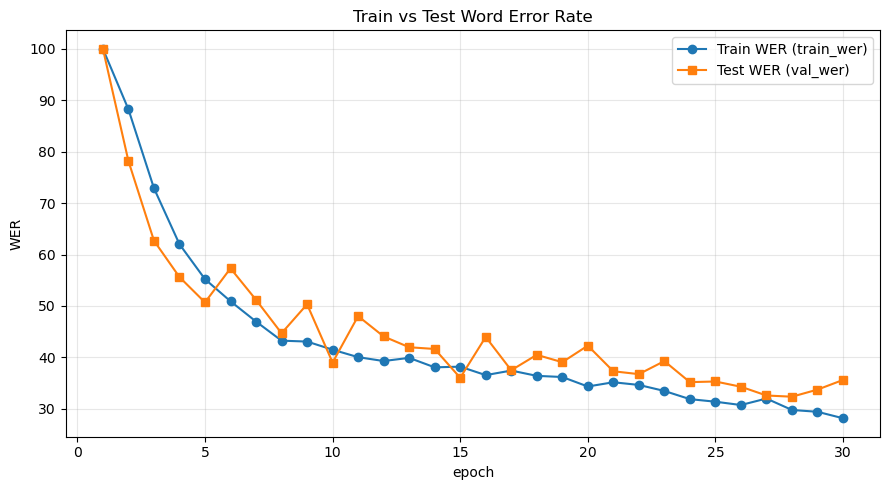

In [5]:
import pandas as pd
from pathlib import Path
from matplotlib import pyplot as plt
# Locate CSV
candidates = [
    Path("/home/xz/GOATS422/Notarius/outputs/training2_log.csv"),
    Path("/home/xz/GOATS422/Notarius/outputs/training2_log.csv".replace(".csv", "")),
]
log_path = next((p for p in candidates if p.exists()), None)
if log_path is None:
    raise FileNotFoundError("Could not find 'training2_log.csv' in the current directory.")

# Load log
log_df = pd.read_csv(log_path)

# Resolve columns (case-insensitive)
lower_to_original = {c.lower(): c for c in log_df.columns}

def find_col(*keywords):
    for lc, oc in lower_to_original.items():
        if all(k in lc for k in keywords):
            return oc
    return None

train_wer_col = find_col("train", "wer")
val_wer_col = find_col("val", "wer")

# Fallbacks for alternate naming
if train_wer_col is None:
    train_wer_col = find_col("wer", "tr") or find_col("wer", "train")
if val_wer_col is None:
    val_wer_col = find_col("wer", "val") or find_col("wer", "test")

if train_wer_col is None or val_wer_col is None:
    raise ValueError(f"Could not find train/test WER columns in: {list(log_df.columns)}")

x_col = (
    lower_to_original.get("epoch")
    or lower_to_original.get("step")
    or lower_to_original.get("iteration")
)

x = log_df[x_col] if x_col else log_df.index

plt.figure(figsize=(9, 5))
plt.plot(x, log_df[train_wer_col], marker="o", label=f"Train WER ({train_wer_col})")
plt.plot(x, log_df[val_wer_col], marker="s", label=f"Test WER ({val_wer_col})")
plt.title("Train vs Test Word Error Rate")
plt.xlabel(x_col if x_col else "Index")
plt.ylabel("WER")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()